# Gradient Descent Method Example

## Import the required libraries

In [1]:
import pepflow as pf
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import itertools
from functools import lru_cache
from IPython.display import display, Math

from pepflow.lyapunov_utils import (
    find_symmetric_coefficient_matrix,
    vectors_in_column_space,
    find_basis_with_sparsest_coefficients,
    ldl_decompose_with_reversed_basis,
)

## Define the functions

In [2]:
L = pf.Parameter("L")
f = pf.SmoothConvexFunction(is_basis=True, tags=["f"], L=L)

## Write a function to return the PEPContext associated with GD

In [3]:
def make_ctx_gd(
    ctx_name: str, N: int | sp.Integer, stepsize: pf.Parameter
) -> pf.PEPContext:
    ctx_gd = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    f.set_stationary_point("x_star")
    for i in range(N):
        x = x - 1 / L * f.grad(x)
        x.add_tag(f"x_{i + 1}")
    return ctx_gd

## Numerical evidence of convergence of GD

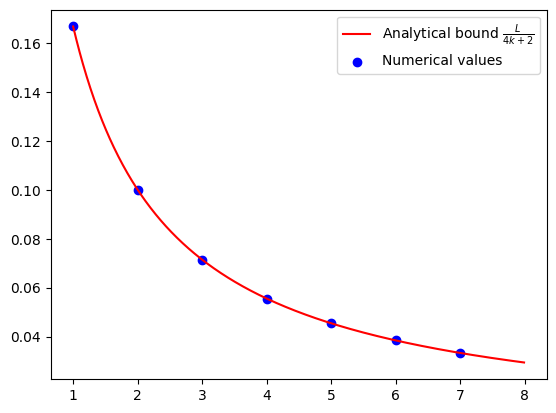

In [4]:
N = 8
R = pf.Parameter("R")
L_value = 1
R_value = 1

ctx_plt = make_ctx_gd(ctx_name="ctx_plt", N=N, stepsize=1 / L)
pb_plt = pf.PEPBuilder(ctx_plt)
pb_plt.add_initial_constraint(
    ((ctx_plt["x_0"] - ctx_plt["x_star"]) ** 2).le(R, name="initial_condition")
)

opt_values = []
for k in range(1, N):
    x_k = ctx_plt[f"x_{k}"]
    pb_plt.set_performance_metric(f(x_k) - f(ctx_plt["x_star"]))
    result = pb_plt.solve(resolve_parameters={"L": L_value, "R": R_value})
    opt_values.append(result.opt_value)

iters = np.arange(1, N)
cont_iters = np.arange(1, N, 0.01)
plt.plot(
    cont_iters,
    L_value / (4 * cont_iters + 2),
    "r-",
    label="Analytical bound $\\frac{L}{4k + 2}$",
)
plt.scatter(iters, opt_values, color="blue", marker="o", label="Numerical values")
plt.legend()

## Verification of convergence of GM

In [5]:
N = sp.S(5)
R = pf.Parameter("R")
L_value = sp.S(1)
R_value = sp.S(1)

ctx_prf = make_ctx_gd(ctx_name="ctx_prf", N=N, stepsize=1 / L)
pb_prf = pf.PEPBuilder(ctx_prf)
pb_prf.add_initial_constraint(
    ((ctx_prf["x_0"] - ctx_prf["x_star"]) ** 2).le(R, name="initial_condition")
)
pb_prf.set_performance_metric(f(ctx_prf[f"x_{N}"]) - f(ctx_prf["x_star"]))

result = pb_prf.solve(resolve_parameters={"L": L_value, "R": R_value})
print(result.opt_value)

# Dual variables associated with the interpolations conditions of f with no relaxation
lamb_dense = result.get_scalar_constraint_dual_value_in_numpy(f)

0.04545413917119227


In [6]:
pf.launch_primal_interactive(
    pb_prf, ctx_prf, resolve_parameters={"L": L_value, "R": R_value}
)

Dash app running on http://127.0.0.1:8050/


### Solve the problem again with the found relaxation

In [7]:
def tag_to_index(tag, N=N):
    """This is a function that takes in a tag of an iterate and returns its index.
    We index "x_star" as "N+1 where N is the last iterate.
    """
    # Split the string on "_" and get the index
    if (idx := tag.split("_")[1]).isdigit():
        return int(idx)
    elif idx == "star":
        return N + 1

In [8]:
relaxed_constraints = []

for tag_i in lamb_dense.row_names:
    i = tag_to_index(tag_i)
    if i == N + 1:
        continue
    for tag_j in lamb_dense.col_names:
        j = tag_to_index(tag_j)
        if i < N and i + 1 == j:
            continue
        relaxed_constraints.append(f"f:{tag_i},{tag_j}")

pb_prf.set_relaxed_constraints(relaxed_constraints)

- Solve the PEP problem again with the relaxed constraints and store the results.


In [9]:
result = pb_prf.solve(resolve_parameters={"L": L_value, "R": R_value})

# Dual variable associated with the initial condition
tau_sol = result.dual_var_manager.dual_value("initial_condition")
# Dual variable associated with the interpolations conditions of f
lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(f)
# Dual variable associated with the Gram matrix G
S_sol = result.get_gram_dual_matrix()

### Verify closed form expression of $\lambda$

- Print the values of $\lambda$ obtained from the solver

In [10]:
lamb_sol.pprint()

<IPython.core.display.Math object>

In [11]:
def lamb(tag_i, tag_j, N=N):
    i = tag_to_index(tag_i)
    j = tag_to_index(tag_j)
    if i == N + 1:  # Additional constraint 1 (between x_★)
        if j == 0:
            return lamb("x_0", "x_1")
        elif j < N:
            return lamb(f"x_{j}", f"x_{j + 1}") - lamb(f"x_{j - 1}", f"x_{j}")
        elif j == N:
            return 1 - lamb(f"x_{N - 1}", f"x_{N}")
    if i < N and i + 1 == j:  # Additional constraint 2 (consecutive)
        return j / (2 * N + 1 - j)
    return 0


lamb_cand = pf.pprint_labeled_matrix(
    lamb, lamb_sol.row_names, lamb_sol.col_names, return_matrix=True
)

<IPython.core.display.Math object>

- Check whether our candidate of $\lambda$ matches with solution

In [12]:
print(
    "Did we guess the right closed form of lambda?",
    np.allclose(lamb_cand, lamb_sol.matrix, atol=1e-4),
)

Did we guess the right closed form of lambda? True


### Verify closed form expression $S$

- Create an ExpressionManager to translate $x_i$, $f(x_i)$, and $\nabla f(x_i)$ into a basis representation

In [13]:
pm = pf.ExpressionManager(ctx_prf, resolve_parameters={"L": L_value, "R": R_value})

- Print the values of $S$ obtained from the solver

In [14]:
S_sol.pprint()

<IPython.core.display.Math object>

- Subtract the decomposed closed-form expressions

In [15]:
x = ctx_prf.tracked_point(f)
x_0 = ctx_prf["x_0"]
x_star = ctx_prf["x_star"]

In [16]:
D, ell = ldl_decompose_with_reversed_basis(
    S_sol, ctx_prf.basis_vectors(), print_output=True
)

<IPython.core.display.Math object>

Matrix([
[0.5,   0.0,   0.0,   0.0,   0.0,   0.0, 0.0, 0.0],
[0.0, 0.819,   0.0,   0.0,   0.0,   0.0, 0.0, 0.0],
[0.0,   0.0, 0.541,   0.0,   0.0,   0.0, 0.0, 0.0],
[0.0,   0.0,   0.0, 0.336,   0.0,   0.0, 0.0, 0.0],
[0.0,   0.0,   0.0,   0.0, 0.179,   0.0, 0.0, 0.0],
[0.0,   0.0,   0.0,   0.0,   0.0, 0.055, 0.0, 0.0],
[0.0,   0.0,   0.0,   0.0,   0.0,   0.0, 0.0, 0.0],
[0.0,   0.0,   0.0,   0.0,   0.0,   0.0, 0.0, 0.0]])

- Guess a closed form for $\ell$ based on numerical observations.

In [17]:
z = []
for i in range(N + 1):
    z_i_guess = (x[i] - x_star) / sp.S(2 * N + 1 - i) - 1 / L * f.grad(x[i])
    remainder_1 = pm.eval_vector(z_i_guess + ell[N - i]).coords
    pf.pprint_labeled_vector(remainder_1, S_sol.row_names)
    z.append(z_i_guess)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

- Double check the calculation

In [18]:
S_guess = pf.Scalar.zero()

# Even though we don't find this closed form, we may find such decomposition numerically

delta = []
for i in range(N + 1):
    coeff_i = D[N - i, N - i]
    delta.append(coeff_i)
    z[i].add_tag(f"z_{i}")
    S_guess += L * coeff_i * z[i] ** 2

remainder_1 = S_sol.matrix - pm.eval_scalar(S_guess).inner_prod_coords
pf.pprint_labeled_matrix(remainder_1, S_sol.row_names, S_sol.col_names)

<IPython.core.display.Math object>

- Check whether our candidate of $S$ matches with solution

In [19]:
print(
    "Did we guess the right closed form of ell?",
    np.allclose(pm.eval_scalar(S_guess).inner_prod_coords, S_sol.matrix, atol=1e-4),
)

Did we guess the right closed form of ell? True


---

In [20]:
ctx_prf.set_as_current()
ctx_prf.basis_vectors()

[x_0,
 x_star,
 grad_f(x_0),
 grad_f(x_1),
 grad_f(x_2),
 grad_f(x_3),
 grad_f(x_4),
 grad_f(x_5)]

In [21]:
lyap_basis_candidate = ctx_prf.basis_vectors()
lyap_basis_candidate += x

# Add any two difference between special vectors as new special vectors
for i, j in itertools.combinations(range(len(lyap_basis_candidate)), 2):
    diff = lyap_basis_candidate[i] - lyap_basis_candidate[j]
    lyap_basis_candidate.append(diff)

In [22]:
lyap_basis_candidate

[x_0,
 x_star,
 grad_f(x_0),
 grad_f(x_1),
 grad_f(x_2),
 grad_f(x_3),
 grad_f(x_4),
 grad_f(x_5),
 x_0,
 x_1,
 x_2,
 x_3,
 x_4,
 x_5,
 x_star,
 x_0-x_star,
 x_0-grad_f(x_0),
 x_0-grad_f(x_1),
 x_0-grad_f(x_2),
 x_0-grad_f(x_3),
 x_0-grad_f(x_4),
 x_0-grad_f(x_5),
 x_0-x_0,
 x_0-(x_1),
 x_0-(x_2),
 x_0-(x_3),
 x_0-(x_4),
 x_0-(x_5),
 x_0-x_star,
 x_star-grad_f(x_0),
 x_star-grad_f(x_1),
 x_star-grad_f(x_2),
 x_star-grad_f(x_3),
 x_star-grad_f(x_4),
 x_star-grad_f(x_5),
 x_star-x_0,
 x_star-(x_1),
 x_star-(x_2),
 x_star-(x_3),
 x_star-(x_4),
 x_star-(x_5),
 x_star-x_star,
 grad_f(x_0)-grad_f(x_1),
 grad_f(x_0)-grad_f(x_2),
 grad_f(x_0)-grad_f(x_3),
 grad_f(x_0)-grad_f(x_4),
 grad_f(x_0)-grad_f(x_5),
 grad_f(x_0)-x_0,
 grad_f(x_0)-(x_1),
 grad_f(x_0)-(x_2),
 grad_f(x_0)-(x_3),
 grad_f(x_0)-(x_4),
 grad_f(x_0)-(x_5),
 grad_f(x_0)-x_star,
 grad_f(x_1)-grad_f(x_2),
 grad_f(x_1)-grad_f(x_3),
 grad_f(x_1)-grad_f(x_4),
 grad_f(x_1)-grad_f(x_5),
 grad_f(x_1)-x_0,
 grad_f(x_1)-(x_1),
 grad_f(x_1

## Identify the vectors composing the Lyapunov function

Compute the sum of active inequalities up to k-th iteration

In [23]:
lyap = [pf.Scalar.zero()]
partial_sum = 0
partial_sum -= delta[0] * ell[N] ** 2
partial_sum += lamb("x_star", f"x_{0}") * f.interp_ineq("x_star", f"x_{0}")
for j in np.arange(N):
    partial_sum += lamb(f"x_{j}", f"x_{j + 1}") * f.interp_ineq(f"x_{j}", f"x_{j + 1}")
    partial_sum += lamb("x_star", f"x_{j + 1}") * f.interp_ineq("x_star", f"x_{j + 1}")
    partial_sum -= delta[j + 1] * ell[N - j - 1] ** 2
    lyap.append(partial_sum)

In [24]:
for k in range(len(lyap)):
    lyap_numeric_k = pm.eval_scalar(lyap[k]).inner_prod_coords.astype(float)
    print(f"Rank of lyap[{k}]: {np.linalg.matrix_rank(lyap_numeric_k, tol=1e-4)}")

Rank of lyap[0]: 0
Rank of lyap[1]: 3
Rank of lyap[2]: 3
Rank of lyap[3]: 3
Rank of lyap[4]: 3
Rank of lyap[5]: 1


#### Extract the special vectors representing lyap[k] = V_{k+1}

In [25]:
for k in range(1, len(lyap)):
    print(
        f"V_{k}:",
        vectors_in_column_space(
            lyap[k],
            lyap_basis_candidate,
            ctx_prf,
            resolve_parameters=pm.resolve_parameters,
            rtol=1e-4,
            atol=1e-4,
        ),
    )

V_1: [grad_f(x_0), grad_f(x_1), x_0-x_star, x_0-x_0, x_0-(x_1), x_0-(x_2), x_0-x_star, x_star-x_0, x_star-(x_1), x_star-(x_2), x_star-x_star, grad_f(x_0)-grad_f(x_1), x_0-(x_1), x_0-(x_2), x_0-x_star, x_1-(x_2), x_1-x_star, x_2-x_star]
V_2: [grad_f(x_2), x_0-x_star, x_0-x_0, x_0-(x_2), x_0-(x_3), x_0-x_star, x_star-x_0, x_star-(x_2), x_star-(x_3), x_star-x_star, x_0-(x_2), x_0-(x_3), x_0-x_star, x_2-(x_3), x_2-x_star, x_3-x_star]
V_3: [grad_f(x_3), x_0-x_star, x_0-x_0, x_0-(x_3), x_0-(x_4), x_0-x_star, x_star-x_0, x_star-(x_3), x_star-(x_4), x_star-x_star, x_0-(x_3), x_0-(x_4), x_0-x_star, x_3-(x_4), x_3-x_star, x_4-x_star]
V_4: [grad_f(x_4), x_0-x_star, x_0-x_0, x_0-(x_4), x_0-(x_5), x_0-x_star, x_star-x_0, x_star-(x_4), x_star-(x_5), x_star-x_star, x_0-(x_4), x_0-(x_5), x_0-x_star, x_4-(x_5), x_4-x_star, x_5-x_star]
V_5: [x_0-x_star, x_0-x_0, x_0-x_star, x_star-x_0, x_star-x_star, x_0-x_star]


#### Collecting good linearly independent vectors

In [26]:
for k in range(1, len(lyap) - 1):
    aligned_special_vectors_k = vectors_in_column_space(
        lyap[k],
        lyap_basis_candidate,
        ctx_prf,
        resolve_parameters=pm.resolve_parameters,
        rtol=1e-4,
        atol=1e-4,
    )
    best_vectors, best_coefficients = find_basis_with_sparsest_coefficients(
        lyap[k],
        aligned_special_vectors_k,
        pep_context=ctx_prf,
        resolve_parameters=pm.resolve_parameters,
    )
    labels_k = [str(v) for v in best_vectors]
    print(f"lyap[{k}]:")
    pf.pprint_labeled_matrix(best_coefficients, labels_k, labels_k)

lyap[1]:


<IPython.core.display.Math object>

lyap[2]:


<IPython.core.display.Math object>

lyap[3]:


<IPython.core.display.Math object>

lyap[4]:


<IPython.core.display.Math object>

#### Guess the generic basis vectors based on above observation

In [27]:
@lru_cache(None)
def V_k_basis(k: int, N=N):
    if k == N:
        return [x[0] - x_star]
    return [x[0] - x_star, f.grad(x[k]), x[k + 1] - x_star]

In [28]:
for k in range(1, len(lyap)):
    print(f"V_{k}:", V_k_basis(k))

V_1: [x_0-x_star, grad_f(x_1), x_2-x_star]
V_2: [x_0-x_star, grad_f(x_2), x_3-x_star]
V_3: [x_0-x_star, grad_f(x_3), x_4-x_star]
V_4: [x_0-x_star, grad_f(x_4), x_5-x_star]
V_5: [x_0-x_star]


---

In [29]:
@lru_cache(None)
def V_k_basis_labels(k: int, N=N):
    return [str(x) for x in V_k_basis(k)]


def print_numeric_coefficients(k):
    lyap_k_coeff = find_symmetric_coefficient_matrix(
        lyap[k],
        V_k_basis(k),
        pep_context=ctx_prf,
        resolve_parameters=pm.resolve_parameters,
    )
    pf.pprint_labeled_matrix(lyap_k_coeff, V_k_basis_labels(k), V_k_basis_labels(k))
    pf.pprint_labeled_vector(
        pm.eval_scalar(lyap[k]).func_coords.astype(float),
        [str(x) for x in ctx_prf.basis_scalars()],
    )

In [30]:
for k in range(1, len(lyap)):
    print(f"V_{k}:")
    print_numeric_coefficients(k)

V_1:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

V_2:


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

V_5:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Finding the coefficient of Lyapunov function: symbolic

In [31]:
ctx_gd_lyap = pf.PEPContext("gd_lyap_finder").set_as_current()

In [32]:
k = pf.Parameter("k")
N = pf.Parameter("N")
L = pf.Parameter("L")
alpha = 1 / L

f.set_stationary_point("x_star")
x_star = ctx_gd_lyap["x_star"]
x_0 = pf.Vector(is_basis=True, tags=["x_0"])
x_k = pf.Vector(is_basis=True, tags=["x_k"])

x_k1 = x_k - alpha * f.grad(x_k)
x_k1.add_tag("x_{k+1}")

x_k2 = x_k1 - alpha * f.grad(x_k1)
x_k2.add_tag("x_{k+2}")

a_k = pf.Parameter("a_k")
a_k1 = pf.Parameter("a_{k+1}")
b_k = pf.Parameter("b_k")
b_k1 = pf.Parameter("b_{k+1}")
c_k = pf.Parameter("c_k")
c_k1 = pf.Parameter("c_{k+1}")
d_k = pf.Parameter("d_k")
d_k1 = pf.Parameter("d_{k+1}")

s_k1 = pf.Parameter("s_{N-k-1}")
lamb_k_k1 = pf.Parameter(r"\lambda_{k,k+1}")
# lamb_k_k1 = (k+1)/(2*N-k)
lamb_star_k1 = pf.Parameter(r"\lambda_{star,k+1}")
# lamb_star_k1 = (k+2)/(2*N-k-1) - lamb_k_k1

In [33]:
V_k_prev = (
    a_k * (f(x_k) - f(x_star))
    + b_k * f.grad(x_k) ** 2
    + c_k * (x_k1 - x_star) ** 2
    + d_k * (x_0 - x_star) ** 2
)
V_k = (
    a_k1 * (f(x_k1) - f(x_star))
    + b_k1 * f.grad(x_k1) ** 2
    + c_k1 * (x_k2 - x_star) ** 2
    + d_k1 * (x_0 - x_star) ** 2
)

LHS = V_k - V_k_prev
LHS

a_{k+1}*(f(x_{k+1})-f(x_star))+b_{k+1}*|grad_f(x_{k+1})|^2+c_{k+1}*|x_{k+2}-x_star|^2+d_{k+1}*|x_0-x_star|^2-(a_k*(f(x_k)-f(x_star))+b_k*|grad_f(x_k)|^2+c_k*|x_{k+1}-x_star|^2+d_k*|x_0-x_star|^2)

In [34]:
RHS = lamb_k_k1 * f.interp_ineq("x_k", "x_{k+1}")
RHS += lamb_star_k1 * f.interp_ineq("x_star", "x_{k+1}")
RHS -= s_k1 * ((x_k1 - x_star) / (2 * N - k) - f.grad(x_k1)) ** 2

RHS

\lambda_{k,k+1}*(f(x_{k+1})-f(x_k)+⟨grad_f(x_{k+1}),x_k-(x_{k+1})⟩+1/2*L*|grad_f(x_k)-grad_f(x_{k+1})|^2)+\lambda_{star,k+1}*(f(x_{k+1})-f(x_star)+⟨grad_f(x_{k+1}),x_star-(x_{k+1})⟩+1/2*L*|grad_f(x_star)-grad_f(x_{k+1})|^2)-s_{N-k-1}*|1/2*N-k*(x_{k+1}-x_star)-grad_f(x_{k+1})|^2

In [35]:
diff = LHS - RHS

diff

a_{k+1}*(f(x_{k+1})-f(x_star))+b_{k+1}*|grad_f(x_{k+1})|^2+c_{k+1}*|x_{k+2}-x_star|^2+d_{k+1}*|x_0-x_star|^2-(a_k*(f(x_k)-f(x_star))+b_k*|grad_f(x_k)|^2+c_k*|x_{k+1}-x_star|^2+d_k*|x_0-x_star|^2)-(\lambda_{k,k+1}*(f(x_{k+1})-f(x_k)+⟨grad_f(x_{k+1}),x_k-(x_{k+1})⟩+1/2*L*|grad_f(x_k)-grad_f(x_{k+1})|^2)+\lambda_{star,k+1}*(f(x_{k+1})-f(x_star)+⟨grad_f(x_{k+1}),x_star-(x_{k+1})⟩+1/2*L*|grad_f(x_star)-grad_f(x_{k+1})|^2)-s_{N-k-1}*|1/2*N-k*(x_{k+1}-x_star)-grad_f(x_{k+1})|^2)

In [36]:
basis_vectors = ctx_gd_lyap.basis_vectors()
vec_index = [str(v) for v in basis_vectors]

basis_scalars = ctx_gd_lyap.basis_scalars()
scal_index = [str(v) for v in basis_scalars]

In [37]:
a_k_sp, a_k1_sp, b_k_sp, b_k1_sp, c_k_sp, c_k1_sp, d_k_sp, d_k1_sp, N_sp, k_sp, L_sp = (
    sp.symbols("a_k a_{k+1} b_k b_{k+1} c_k c_{k+1} d_k d_{k+1} N k L")
)
s_k1_sp = sp.Symbol("s_{N-k-1}")
lamb_k_k1_sp = sp.Symbol(lamb_k_k1.name)
lamb_star_k1_sp = sp.Symbol(lamb_star_k1.name)

pm_lyap = pf.ExpressionManager(
    ctx_gd_lyap,
    resolve_parameters={
        "a_k": a_k_sp,
        "a_{k+1}": a_k1_sp,
        "b_k": b_k_sp,
        "b_{k+1}": b_k1_sp,
        "c_k": c_k_sp,
        "c_{k+1}": c_k1_sp,
        "d_k": d_k_sp,
        "d_{k+1}": d_k1_sp,
        "s_{N-k-1}": s_k1_sp,
        lamb_k_k1.name: lamb_k_k1_sp,
        lamb_star_k1.name: lamb_star_k1_sp,
        "N": N_sp,
        "k": k_sp,
        "L": L_sp,
    },
)

In [38]:
diff_matrix = pm_lyap.eval_scalar(diff).inner_prod_coords
pf.pprint_labeled_matrix(diff_matrix, vec_index, vec_index, precision=None)

<IPython.core.display.Math object>

In [39]:
diff_vec = pm_lyap.eval_scalar(diff).func_coords
pf.pprint_labeled_vector(diff_vec, scal_index, precision=None)

<IPython.core.display.Math object>

In [40]:
diff_matrix_sympify = sp.Matrix(diff_matrix)
diff_vec_sympify = sp.Matrix(diff_vec)

# unknowns = (a_k_sp, a_k1_sp, b_k_sp, b_k1_sp, c_k_sp, c_k1_sp, d_k_sp, d_k1_sp, s_k1_sp, lamb_k_k1_sp, lamb_star_k1_sp)
# unknowns = (a_k_sp, a_k1_sp, b_k_sp, b_k1_sp, c_k_sp, c_k1_sp, d_k_sp, d_k1_sp, s_k1_sp)
unknowns = (a_k_sp, a_k1_sp, b_k_sp, b_k1_sp, c_k_sp, c_k1_sp, d_k_sp)

eqs = list(diff_matrix_sympify)
eqs += list(diff_vec_sympify)
eqs = [e for e in eqs]

sol = sp.linsolve(eqs, unknowns)
sol_simplify = sp.factor(sp.factor(sp.nsimplify(sol)))
# sol_simplify = sp.nsimplify(sol)

print("Solutions:")
sol_dict = dict(zip(unknowns, next(iter(sol_simplify))))
display(Math(sp.latex(sol_dict)))

Solutions:


<IPython.core.display.Math object>

Double check we found the right solution

In [41]:
if sol:
    print("\nVerification:")
    display(sp.simplify(diff_matrix_sympify.subs(sol_dict)))
    display(sp.simplify(diff_vec_sympify.subs(sol_dict)))


Verification:


Matrix([
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0],
[0, 0, 0, 0, 0]])

Matrix([
[0],
[0],
[0]])